In [1]:
import torch

In [2]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

In [3]:
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='.', train=True, download=True)
fm_test = FashionMNIST(root='.', train=False, download=True)

In [4]:
print(fm_train.data.shape, fm_test.data.shape)
print(fm_train.targets.shape, fm_test.targets.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])
torch.Size([60000]) torch.Size([10000])


In [5]:
train_input = fm_train.data
train_target = fm_train.targets

In [6]:
train_scaled = train_input.reshape(-1,1,28,28) / 255.0

In [7]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

### nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True)
파이토치(PyTorch)에서 제공하는 2D 컨볼루션(Convolution) 레이어 클래스로 이미지나 2D 데이터의 특징 추출에 주로 사용된다.
- in_channels (int): 입력 채널의 개수. 예를 들어, RGB 이미지의 경우 3개의 채널을 가지므로 in_channels는 3이 됩니다.
- out_channels (int): 출력 채널의 개수, 즉 컨볼루션 필터의 개수입니다. 이 값이 클수록 더 복잡한 특징을 학습할 수 있지만, 모델의 파라미터 수가 증가하게 됩니다.
- kernel_size (int 또는 tuple): 컨볼루션 필터의 크기. 예를 들어, 3x3 필터의 경우 kernel_size는 3 또는 (3, 3)으로 지정할 수 있습니다.
- stride (int 또는 tuple, optional): 필터의 이동 간격, 즉 스트라이드(stride)입니다. 기본값은 1이며, 더 큰 값으로 설정하면 출력 특징 맵의 크기가 작아지게 됩니다.
- padding (int 또는 tuple, optional): 입력 데이터의 가장자리에 추가되는 패딩의 크기입니다. 기본값은 0이며, 패딩을 사용하면 출력 특징 맵의 크기를 보존하면서 입력 데이터의 가장자리 정보를 유지할 수 있습니다.
- dilation (int 또는 tuple, optional): 딜레이션(dilation) 레이트입니다. 딜레이션은 필터의 간격을 더 크게 두어 더 넓은 영역의 정보를 가져오는 데 사용됩니다. 기본값은 1이며, 값이 커질수록 필터의 영역이 더 넓어지게 됩니다.
- groups (int, optional): 입력 및 출력 채널을 묶는(grouping) 개수입니다. 기본값은 1이며, 값이 크면 채널 간의 관련성을 줄이는 효과가 있습니다.
- bias (bool, optional): 편향(bias)을 사용할지 여부를 결정하는 플래그입니다. 기본값은 True이며, False로 설정하면 편향이 사용되지 않습니다.

In [8]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1,32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten()) # 입력층
model.add_module('dense1', nn.Linear(3136,100)) # 은닉층
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dense2', nn.Linear(100,10)) # 출력층

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=3136, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=100, out_features=10, bias=True)
)

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 다중 분류, 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [12]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 2 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 20
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달
        loss = criterion(outputs, targets) # 손실값 계산
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_cnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.5179, 검증 손실:0.3427
에포크:2, 훈련 손실:0.3406, 검증 손실:0.2961
에포크:3, 훈련 손실:0.2886, 검증 손실:0.2626
에포크:4, 훈련 손실:0.2588, 검증 손실:0.2445
에포크:5, 훈련 손실:0.2331, 검증 손실:0.2332
에포크:6, 훈련 손실:0.2151, 검증 손실:0.2267
에포크:7, 훈련 손실:0.1966, 검증 손실:0.2280
에포크:8, 훈련 손실:0.1789, 검증 손실:0.2117
에포크:9, 훈련 손실:0.1649, 검증 손실:0.2181
에포크:10, 훈련 손실:0.1492, 검증 손실:0.2228
10번째 에포크에서 조기 종료되었습니다.


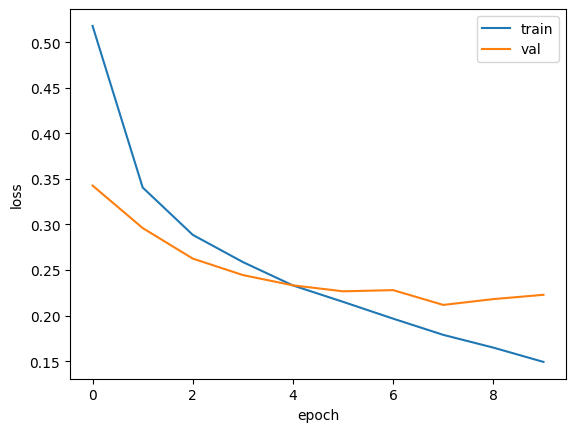

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [14]:
model.load_state_dict(torch.load('best_cnn_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [15]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(val_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9221


In [16]:
test_scaled = fm_test.data.reshape(-1,1,28,28) / 255.0
test_target = fm_test.targets

In [17]:
test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9150
